# 🗺️ AI-Based Autonomous Navigation System
## Notebook 3 — Path Planning & Decision Making Demo
### A* Search Visualization + FSM State Simulation + Obstacle Avoidance

**What you'll learn:**
1. How A* computes the optimal path on a grid
2. How obstacle inflation creates safety buffers
3. How the FSM cycles through state transitions
4. How replanning works when a new obstacle is detected

---

In [1]:
# Setup
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import json, time, math

from src.navigation.planner           import astar, snap_to_grid
from src.navigation.controller        import smooth_path
from src.navigation.decision_maker    import DecisionMaker
from src.navigation.obstacle_avoidance import ObstacleAvoidance
from src.simulation.map_loader        import build_obstacle_set
from src.config import GRID_SIZE, WIDTH, HEIGHT, START_POS, GOAL_POS

print('✅ All modules ready')

C:\Users\kusan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
✅ All modules ready


## Part A — A* Path Planning on the Simulation Grid

In [2]:
# ──────────────────────────────────────────────
# A1: Build the map obstacle set
# ──────────────────────────────────────────────
print('Building map obstacle grid...')
t0 = time.time()
map_obstacles = build_obstacle_set()
t1 = time.time()

cols = WIDTH  // GRID_SIZE
rows = HEIGHT // GRID_SIZE
total_cells = cols * rows
wall_cells  = len(map_obstacles)
road_cells  = total_cells - wall_cells

print(f'Grid size   : {cols} × {rows} = {total_cells} cells')
print(f'Road cells  : {road_cells} ({road_cells/total_cells*100:.1f}%)')
print(f'Wall cells  : {wall_cells} ({wall_cells/total_cells*100:.1f}%)')
print(f'Build time  : {(t1-t0)*1000:.2f} ms')

Building map obstacle grid...
Grid size   : 45 × 32 = 1440 cells
Road cells  : 860 (59.7%)
Wall cells  : 580 (40.3%)
Build time  : 8.30 ms


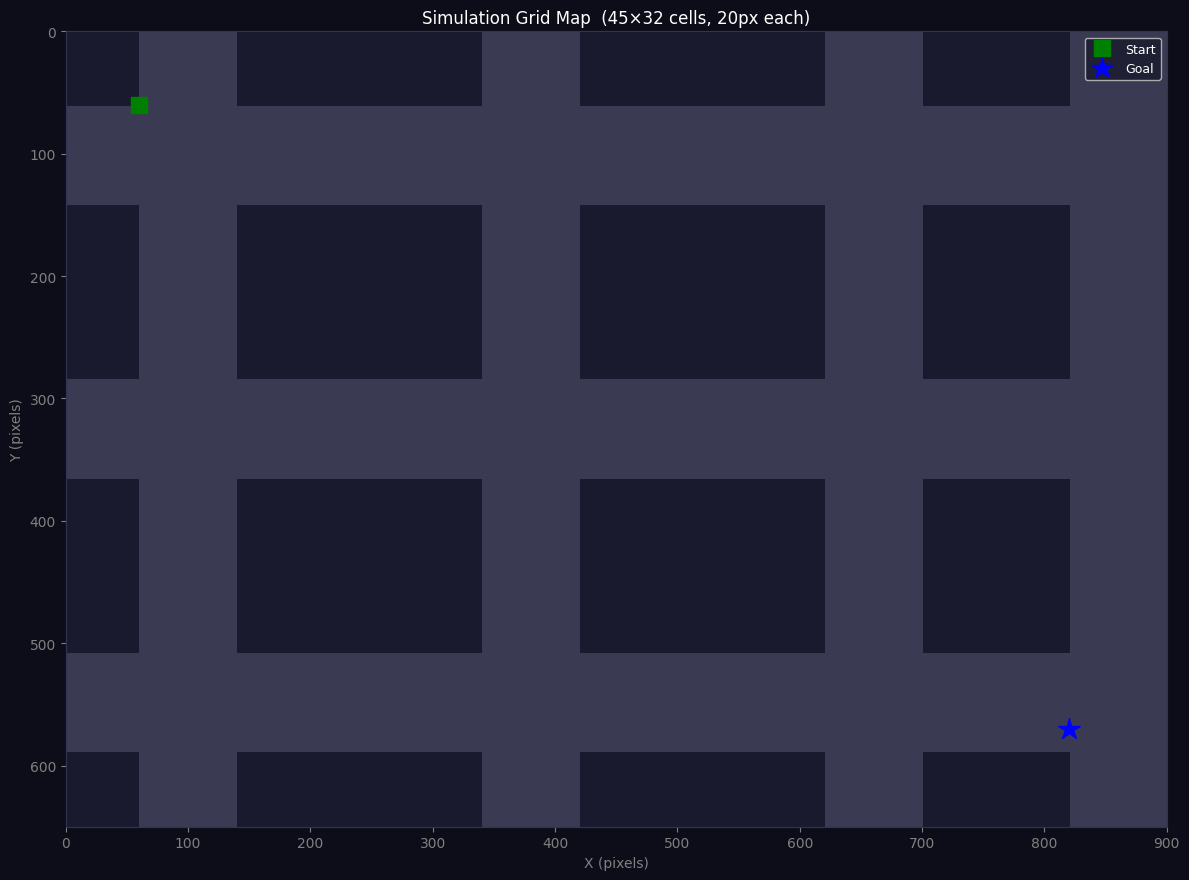

Saved → outputs/screenshots/grid_map.png


In [3]:
# ──────────────────────────────────────────────
# A2: Render the grid map
# ──────────────────────────────────────────────
grid = np.zeros((rows, cols), dtype=np.uint8)  # 0 = road (passable)
for (gx, gy) in map_obstacles:
    col = gx // GRID_SIZE
    row = gy // GRID_SIZE
    if 0 <= col < cols and 0 <= row < rows:
        grid[row, col] = 1  # 1 = wall

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0d0d1a')

cmap = LinearSegmentedColormap.from_list('roadmap',
    ['#3a3a52', '#1a1a2e'], N=2)  # road=light, wall=dark
ax.imshow(grid, cmap=cmap, origin='upper',
          extent=[0, WIDTH, HEIGHT, 0], aspect='equal')

# Mark start and goal
ax.plot(START_POS[0], START_POS[1], 'gs', ms=12, label='Start', zorder=5)
ax.plot(GOAL_POS[0],  GOAL_POS[1],  'b*', ms=16, label='Goal', zorder=5)

ax.set_title(f'Simulation Grid Map  ({cols}×{rows} cells, {GRID_SIZE}px each)',
             color='white', fontsize=12)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_xlabel('X (pixels)', color='gray')
ax.set_ylabel('Y (pixels)', color='gray')
ax.tick_params(colors='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'grid_map.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved → outputs/screenshots/grid_map.png')

In [4]:
# ──────────────────────────────────────────────
# A3: Run A* and visualize the raw path
# ──────────────────────────────────────────────
print(f'Planning A* path: {START_POS} → {GOAL_POS}...')
t0 = time.time()
raw_path = astar(START_POS, GOAL_POS, map_obstacles)
t1 = time.time()

print(f'Path found     : {len(raw_path)} waypoints')
print(f'Planning time  : {(t1-t0)*1000:.2f} ms')
if raw_path:
    path_len_px = sum(
        math.sqrt((raw_path[i][0]-raw_path[i-1][0])**2 +
                  (raw_path[i][1]-raw_path[i-1][1])**2)
        for i in range(1, len(raw_path))
    )
    print(f'Path length    : {path_len_px:.0f} pixels ({path_len_px/GRID_SIZE:.1f} grid cells)')

Planning A* path: (60, 60) → (820, 570)...
Path found     : 49 waypoints
Planning time  : 13.56 ms
Path length    : 1084 pixels (54.2 grid cells)


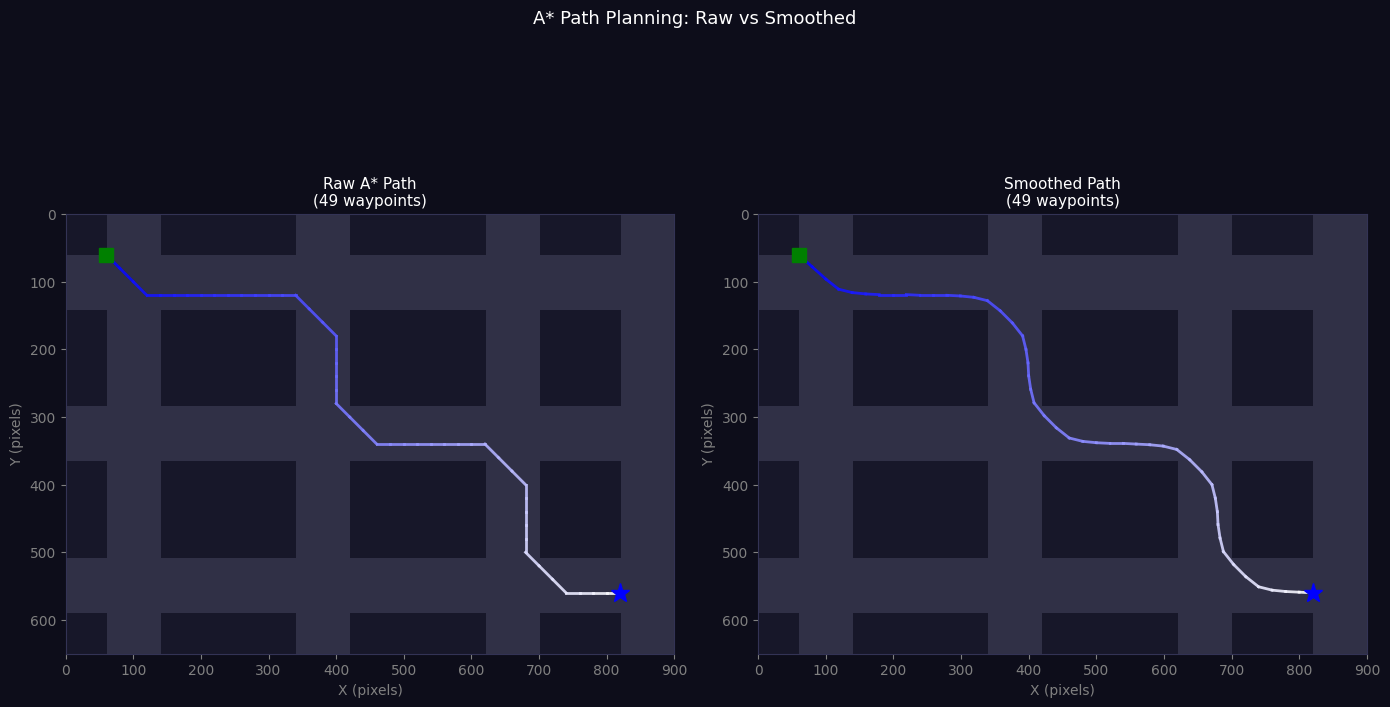

Saved → outputs/screenshots/astar_paths.png


In [5]:
# ──────────────────────────────────────────────
# A4: Path smoothing comparison
# ──────────────────────────────────────────────
smoothed_path = smooth_path(raw_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0d0d1a')

for i, (path, label) in enumerate([(raw_path, 'Raw A* Path'), (smoothed_path, 'Smoothed Path')]):
    ax = axes[i]
    ax.imshow(grid, cmap=cmap, origin='upper',
              extent=[0, WIDTH, HEIGHT, 0], aspect='equal', alpha=0.8)
    ax.set_facecolor('#0d0d1a')

    if path:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        # Color gradient: blue(start) → white(end)
        n = len(path)
        for j in range(1, n):
            t = j / n
            color = (t, t, 1.0)
            ax.plot([xs[j-1], xs[j]], [ys[j-1], ys[j]],
                    color=color, linewidth=2, alpha=0.9)
        ax.plot(xs[0], ys[0], 'gs', ms=10, zorder=5)
        ax.plot(xs[-1], ys[-1], 'b*', ms=14, zorder=5)

    ax.set_title(f'{label}\n({len(path)} waypoints)', color='white', fontsize=11)
    ax.set_xlabel('X (pixels)', color='gray')
    ax.set_ylabel('Y (pixels)', color='gray')
    ax.tick_params(colors='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('A* Path Planning: Raw vs Smoothed', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'astar_paths.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved → outputs/screenshots/astar_paths.png')

---
## Part B — Obstacle Inflation & Dynamic Replanning

In [7]:
# ──────────────────────────────────────────────
# B1: Show effect of obstacle inflation
# ──────────────────────────────────────────────
from src.navigation.obstacle_avoidance import ObstacleAvoidance

oa = ObstacleAvoidance()

# Add a mid-path obstacle
new_obstacle = {(380, 300)}     # right on the path
oa.add_runtime_obstacles(list(new_obstacle))

# Without inflation
path_no_inflate = astar(START_POS, GOAL_POS, map_obstacles | new_obstacle)

# With inflation (ObstacleAvoidance.replan)
path_inflated = oa.replan(
    car_pos=START_POS,
    goal_pos=GOAL_POS,
    static_obstacles=map_obstacles,
)

inflated_set = oa.get_all_obstacles(map_obstacles)

print(f'Raw path (no inflation)   : {len(path_no_inflate)} waypoints')
print(f'Safe path (with inflation): {len(path_inflated)} waypoints')
print(f'Obstacle cells inflated   : {len(inflated_set)} (vs {len(map_obstacles)} original)')

Raw path (no inflation)   : 49 waypoints
Safe path (with inflation): 0 waypoints
Obstacle cells inflated   : 1044 (vs 580 original)


C:\Users\kusan\AppData\Local\Temp\ipykernel_20720\1763728585.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)


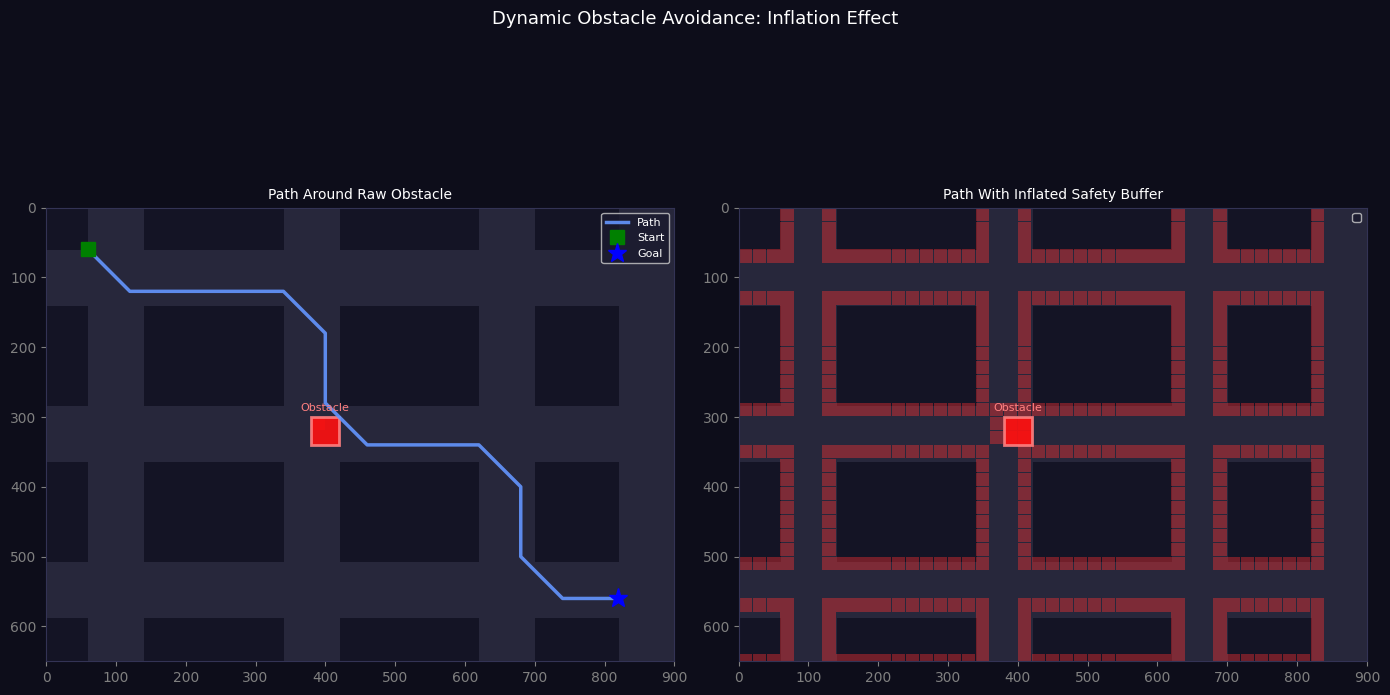

In [8]:
# ──────────────────────────────────────────────
# B2: Visualize inflation effect
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0d0d1a')

plot_data = [
    (path_no_inflate, map_obstacles | new_obstacle, 'Path Around Raw Obstacle'),
    (path_inflated,   inflated_set,                 'Path With Inflated Safety Buffer'),
]

for ax, (path, obs_set, title) in zip(axes, plot_data):
    # Base grid
    ax.imshow(grid, cmap=cmap, origin='upper',
              extent=[0, WIDTH, HEIGHT, 0], aspect='equal', alpha=0.6)
    ax.set_facecolor('#0d0d1a')

    # Show inflated obstacles as red squares
    for (ox, oy) in obs_set:
        if (ox, oy) not in map_obstacles:
            ax.add_patch(patches.Rectangle(
                (ox, oy), GRID_SIZE-1, GRID_SIZE-1,
                facecolor='#ff3232', alpha=0.4, edgecolor='none'
            ))

    # New obstacle (bright red)
    for (ox, oy) in new_obstacle:
        ax.add_patch(patches.Rectangle(
            (ox, oy), GRID_SIZE*2, GRID_SIZE*2,
            facecolor='#ff1010', alpha=0.9,
            edgecolor='#ff8080', linewidth=2
        ))
        ax.text(ox + GRID_SIZE, oy - 8, 'Obstacle', color='#ff8080',
                fontsize=8, ha='center')

    # Path
    if path:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, '-', color='#6496ff', linewidth=2.5, alpha=0.9, label='Path')
        ax.plot(xs[0], ys[0], 'gs', ms=10, zorder=5, label='Start')
        ax.plot(xs[-1], ys[-1], 'b*', ms=14, zorder=5, label='Goal')

    ax.set_title(title, color='white', fontsize=10)
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

plt.suptitle('Dynamic Obstacle Avoidance: Inflation Effect', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'obstacle_inflation.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Part C — FSM Decision Maker Simulation

In [9]:
# ──────────────────────────────────────────────
# C1: Simulate FSM state transitions over 200 frames
# ──────────────────────────────────────────────
from src.perception.obstacle_detector import THREAT_CLEAR, THREAT_WARNING, THREAT_DANGER

dm = DecisionMaker()

# Synthetic scenario:
#  0-40:   CLEAR   → DRIVE
# 40-70:   WARNING → SLOW
# 70-160:  DANGER  → STOP (→ eventually AVOID after 90 frames)
# 160-200: CLEAR   → DRIVE → ARRIVE

def get_threat(frame: int) -> str:
    if frame < 40:   return THREAT_CLEAR
    if frame < 70:   return THREAT_WARNING
    if frame < 160:  return THREAT_DANGER
    return THREAT_CLEAR

def get_dist(frame: int) -> float:
    # Steadily approaching goal, arrive at frame 195
    return max(15, 1500 - frame * 7.5)

states_log  = []
speeds_log  = []
threats_log = []
frames_log  = list(range(200))

for f in frames_log:
    threat = get_threat(f)
    dist   = get_dist(f)
    state  = dm.update(threat_level=threat, dist_to_goal=dist)
    speed  = dm.get_speed_factor()
    states_log.append(state)
    speeds_log.append(speed)
    threats_log.append(threat)

# Summarize transitions
from collections import Counter
state_counts = Counter(states_log)
print('FSM State Distribution over 200 frames:')
print('─' * 40)
for state, count in sorted(state_counts.items(), key=lambda x: -x[1]):
    bar = '█' * (count // 4)
    print(f'  {state:<8} : {count:3d} frames  {bar}')

FSM State Distribution over 200 frames:
────────────────────────────────────────
  DRIVE    : 137 frames  ██████████████████████████████████
  SLOW     :  30 frames  ███████
  STOP     :  30 frames  ███████
  ARRIVE   :   2 frames  
  AVOID    :   1 frames  


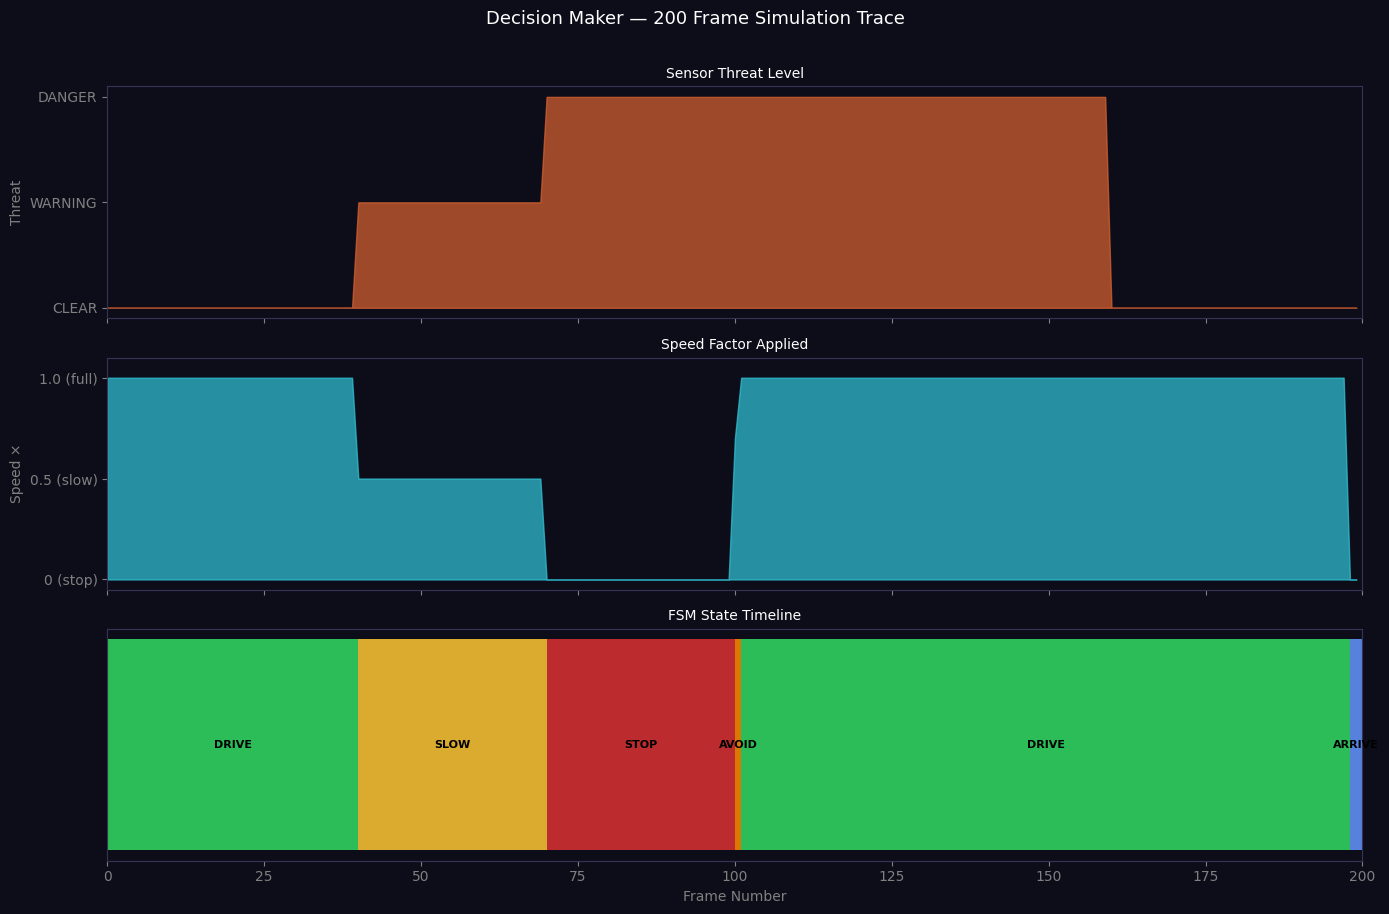

Saved → outputs/screenshots/fsm_timeline.png


In [10]:
# ──────────────────────────────────────────────
# C2: Plot FSM state timeline
# ──────────────────────────────────────────────
state_to_int = {'DRIVE': 4, 'SLOW': 3, 'STOP': 2, 'AVOID': 1, 'ARRIVE': 0}
state_colors = {
    'DRIVE':  '#32dc64',
    'SLOW':   '#ffc832',
    'STOP':   '#dc3232',
    'AVOID':  '#ff8c00',
    'ARRIVE': '#6496ff',
}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor('#0d0d1a')

# Panel 1: Threat level
threat_vals = [{'CLEAR': 0, 'WARNING': 1, 'DANGER': 2}[t] for t in threats_log]
ax1.fill_between(frames_log, threat_vals, color='#dc6432', alpha=0.7)
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['CLEAR', 'WARNING', 'DANGER'], color='gray')
ax1.set_ylabel('Threat', color='gray')
ax1.set_facecolor('#0d0d1a')
ax1.tick_params(colors='gray')
ax1.set_title('Sensor Threat Level', color='white', fontsize=10)
for spine in ax1.spines.values(): spine.set_edgecolor('#333355')

# Panel 2: Speed factor
ax2.fill_between(frames_log, speeds_log, color='#32c8dc', alpha=0.7)
ax2.set_ylim(-0.05, 1.1)
ax2.set_yticks([0, 0.5, 1.0])
ax2.set_yticklabels(['0 (stop)', '0.5 (slow)', '1.0 (full)'], color='gray')
ax2.set_ylabel('Speed ×', color='gray')
ax2.set_facecolor('#0d0d1a')
ax2.tick_params(colors='gray')
ax2.set_title('Speed Factor Applied', color='white', fontsize=10)
for spine in ax2.spines.values(): spine.set_edgecolor('#333355')

# Panel 3: State segments
prev_state = states_log[0]
seg_start  = 0
for i in range(1, len(states_log) + 1):
    curr = states_log[i] if i < len(states_log) else None
    if curr != prev_state or i == len(states_log):
        ax3.barh(0, i - seg_start, left=seg_start, height=0.6,
                 color=state_colors.get(prev_state, '#888888'), alpha=0.85)
        mid = seg_start + (i - seg_start) / 2
        ax3.text(mid, 0, prev_state, ha='center', va='center',
                 fontsize=8, fontweight='bold', color='black')
        seg_start  = i
        prev_state = curr

ax3.set_xlim(0, 200)
ax3.set_yticks([])
ax3.set_xlabel('Frame Number', color='gray')
ax3.set_facecolor('#0d0d1a')
ax3.tick_params(colors='gray')
ax3.set_title('FSM State Timeline', color='white', fontsize=10)
for spine in ax3.spines.values(): spine.set_edgecolor('#333355')

plt.suptitle('Decision Maker — 200 Frame Simulation Trace', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'fsm_timeline.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved → outputs/screenshots/fsm_timeline.png')

---
## Part D — Load & Analyze Sample Path Data

In [11]:
# ──────────────────────────────────────────────
# D1: Load saved path data + analyze
# ──────────────────────────────────────────────
import pandas as pd

path_file = os.path.join(project_root, 'data', 'sample_paths.json')
with open(path_file) as f:
    path_data = json.load(f)

waypoints = path_data['waypoints']
df = pd.DataFrame(waypoints, columns=['x', 'y'])
df['step'] = df.index
df['dx'] = df['x'].diff().fillna(0)
df['dy'] = df['y'].diff().fillna(0)
df['segment_len'] = (df['dx']**2 + df['dy']**2)**0.5
df['cumulative_dist'] = df['segment_len'].cumsum()

print(f'Session     : {path_data["session_id"]}')
print(f'Algorithm   : {path_data["algorithm"]}')
print(f'Waypoints   : {len(waypoints)}')
print(f'Total dist  : {df["cumulative_dist"].iloc[-1]:.0f} px')
print(f'X range     : {df["x"].min()} → {df["x"].max()} px')
print(f'Y range     : {df["y"].min()} → {df["y"].max()} px')
print()
df[['step', 'x', 'y', 'segment_len', 'cumulative_dist']].head(10)

Session     : demo_run_001
Algorithm   : A* (8-directional, octile heuristic)
Waypoints   : 55
Total dist  : 1153 px
X range     : 60 → 820 px
Y range     : 60 → 570 px



,step,x,y,segment_len,cumulative_dist
0,0,60,60,0.000000,0.000000
1,1,80,60,20.000000,20.000000
2,2,100,80,28.284271,48.284271
3,3,100,100,20.000000,68.284271
4,4,100,120,20.000000,88.284271
5,5,100,140,20.000000,108.284271
6,6,100,160,20.000000,128.284271
7,7,100,180,20.000000,148.284271
8,8,100,200,20.000000,168.284271
9,9,120,220,28.284271,196.568542


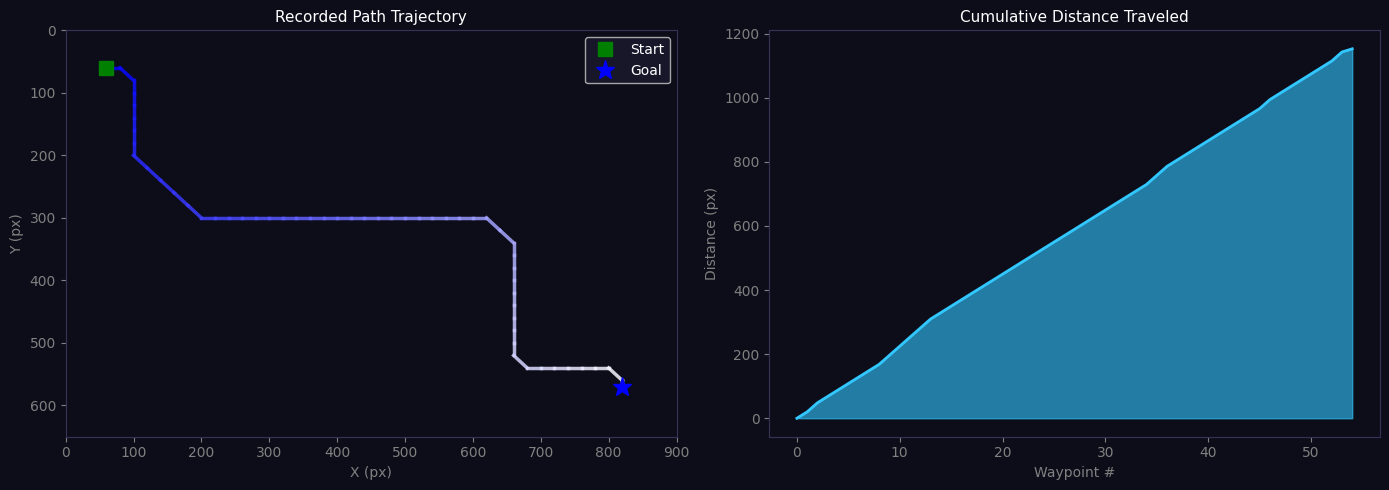

In [12]:
# ──────────────────────────────────────────────
# D2: Plot cumulative distance over waypoints
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d1a')

# Left: X Y trajectory
ax = axes[0]
ax.set_facecolor('#0d0d1a')
n = len(df)
for i in range(1, n):
    t = i / n
    ax.plot([df['x'].iloc[i-1], df['x'].iloc[i]],
            [df['y'].iloc[i-1], df['y'].iloc[i]],
            color=(t, t, 1.0), linewidth=2.5, alpha=0.85)
ax.plot(df['x'].iloc[0], df['y'].iloc[0], 'gs', ms=10, label='Start', zorder=5)
ax.plot(df['x'].iloc[-1], df['y'].iloc[-1], 'b*', ms=14, label='Goal', zorder=5)
ax.set_xlim(0, WIDTH)
ax.set_ylim(HEIGHT, 0)
ax.set_title('Recorded Path Trajectory', color='white', fontsize=11)
ax.set_xlabel('X (px)', color='gray')
ax.set_ylabel('Y (px)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Right: Cumulative distance
ax = axes[1]
ax.set_facecolor('#0d0d1a')
ax.fill_between(df['step'], df['cumulative_dist'], color='#32c8ff', alpha=0.6)
ax.plot(df['step'], df['cumulative_dist'], color='#32c8ff', linewidth=2)
ax.set_title('Cumulative Distance Traveled', color='white', fontsize=11)
ax.set_xlabel('Waypoint #', color='gray')
ax.set_ylabel('Distance (px)', color='gray')
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'path_analysis.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## 🎯 Summary

| What You Demonstrated | Module | Result |
|-----------------------|--------|--------|
| Grid map construction | `map_loader.py` | Road vs wall classification |
| A* path planning | `planner.py` | Optimal 8-directional path |
| Path smoothing | `controller.py` | Reduced angular zig-zag |
| Obstacle inflation | `obstacle_avoidance.py` | Expanded safety buffer |
| FSM simulation | `decision_maker.py` | DRIVE → SLOW → STOP → AVOID → ARRIVE |
| Path data analysis | `data/sample_paths.json` | Trajectory & distance metrics |

---
### ▶️ Run the full simulation
```bash
cd ..   # Go to project root
python main.py
```